<a href="https://colab.research.google.com/github/Thathsara-Devindi/SSTRE-LTNLL/blob/main/LTNLL_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# For check GPU
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
Using: cuda


In [2]:
# Import + reproducibility
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Seed fixed:", SEED)

Seed fixed: 42


In [3]:
# Load CIFAR-10
train_raw = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
)

test_raw = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True
)

print("Original training samples:", len(train_raw))
print("Test samples:", len(test_raw))
print("Classes:", train_raw.classes)

100%|██████████| 170M/170M [00:04<00:00, 35.8MB/s]


Original training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
# Long-tail distribution
clean_targets_full = np.array(train_raw.targets)

NUM_CLASSES = 10
MAX_SAMPLES = 5000
IMBALANCE_RATIO = 10

class_counts_target = []

for c in range(NUM_CLASSES):
    n = int(
        MAX_SAMPLES *
        (1 / IMBALANCE_RATIO) ** (c / (NUM_CLASSES - 1))
    )
    class_counts_target.append(n)

print("Target long-tail class counts:")
for c, n in enumerate(class_counts_target):
    print(f"Class {c}: {n}")

Target long-tail class counts:
Class 0: 5000
Class 1: 3871
Class 2: 2997
Class 3: 2320
Class 4: 1796
Class 5: 1391
Class 6: 1077
Class 7: 834
Class 8: 645
Class 9: 500


In [5]:
# Select actual samples
rng = np.random.default_rng(SEED)

lt_indices = []

for c in range(NUM_CLASSES):
    class_indices = np.where(clean_targets_full == c)[0]
    rng.shuffle(class_indices)

    selected = class_indices[:class_counts_target[c]]
    lt_indices.extend(selected)

lt_indices = np.array(lt_indices)
rng.shuffle(lt_indices)

clean_labels = clean_targets_full[lt_indices]

print("Long-tail training size:", len(lt_indices))

unique, counts = np.unique(clean_labels, return_counts=True)

print("\nActual clean class counts:")
for c, n in zip(unique, counts):
    print(f"Class {c}: {n}")

Long-tail training size: 20431

Actual clean class counts:
Class 0: 5000
Class 1: 3871
Class 2: 2997
Class 3: 2320
Class 4: 1796
Class 5: 1391
Class 6: 1077
Class 7: 834
Class 8: 645
Class 9: 500


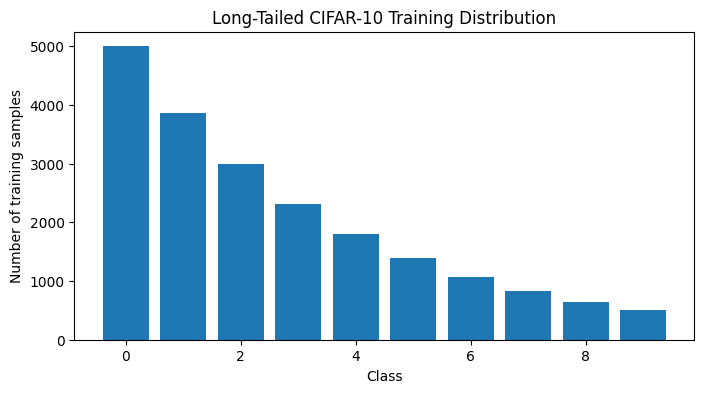

In [6]:
plt.figure(figsize=(8, 4))
plt.bar(range(NUM_CLASSES), class_counts_target)

plt.xlabel("Class")
plt.ylabel("Number of training samples")
plt.title("Long-Tailed CIFAR-10 Training Distribution")

plt.show()

In [7]:
# Symmetric noise
def add_symmetric_noise(clean_labels, noise_rate, num_classes, seed=42):
    rng = np.random.default_rng(seed)

    noisy_labels = clean_labels.copy()

    n_samples = len(clean_labels)
    n_noisy = int(noise_rate * n_samples)

    noisy_indices = rng.choice(
        n_samples,
        size=n_noisy,
        replace=False
    )

    for idx in noisy_indices:
        original = clean_labels[idx]

        possible_labels = list(range(num_classes))
        possible_labels.remove(int(original))

        noisy_labels[idx] = rng.choice(possible_labels)

    is_noisy = noisy_labels != clean_labels

    return noisy_labels, is_noisy


NOISE_RATE = 0.20

noisy_labels, is_noisy = add_symmetric_noise(
    clean_labels,
    noise_rate=NOISE_RATE,
    num_classes=NUM_CLASSES,
    seed=SEED
)

print("Training samples:", len(clean_labels))
print("Noisy samples:", is_noisy.sum())
print("Actual noise rate:", is_noisy.mean())

Training samples: 20431
Noisy samples: 4086
Actual noise rate: 0.19999021095394254


In [8]:
# Research metadata table
sample_info = pd.DataFrame({
    "dataset_index": lt_indices,
    "clean_label": clean_labels,
    "noisy_label": noisy_labels,
    "is_noisy": is_noisy
})

sample_info.head(10)

,dataset_index,clean_label,noisy_label,is_noisy
0,25276,2,2,False
1,29468,0,0,False
2,18395,8,8,False
3,13244,1,1,False
4,4265,1,1,False
5,25116,7,7,False
6,34523,8,8,False
7,17815,1,1,False
8,36822,3,3,False
9,20338,3,5,True


In [9]:
class_order = np.argsort(-np.array(class_counts_target))

head_classes = class_order[:3]
medium_classes = class_order[3:7]
tail_classes = class_order[7:]

print("Head classes:", head_classes)
print("Medium classes:", medium_classes)
print("Tail classes:", tail_classes)

def get_group(label):
    if label in head_classes:
        return "Head"
    elif label in medium_classes:
        return "Medium"
    else:
        return "Tail"

sample_info["group"] = [
    get_group(label)
    for label in sample_info["clean_label"]
]

sample_info["group"].value_counts()

Head classes: [0 1 2]
Medium classes: [3 4 5 6]
Tail classes: [7 8 9]


,count
group,
Head,11868
Medium,6584
Tail,1979


In [10]:
clean_tail_mask = (
    (~sample_info["is_noisy"]) &
    (sample_info["group"] == "Tail")
)

print("Clean tail samples:", clean_tail_mask.sum())

Clean tail samples: 1577


In [11]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

In [12]:
class LTNLLDataset(Dataset):
    def __init__(
        self,
        base_dataset,
        selected_indices,
        noisy_labels,
        clean_labels,
        transform=None
    ):
        self.base_dataset = base_dataset
        self.selected_indices = selected_indices
        self.noisy_labels = noisy_labels
        self.clean_labels = clean_labels
        self.transform = transform

    def __len__(self):
        return len(self.selected_indices)

    def __getitem__(self, idx):
        original_idx = self.selected_indices[idx]

        image, _ = self.base_dataset[original_idx]

        if self.transform:
            image = self.transform(image)

        noisy_label = int(self.noisy_labels[idx])
        clean_label = int(self.clean_labels[idx])

        return image, noisy_label, clean_label, idx

In [13]:
# Dataloaders
train_dataset = LTNLLDataset(
    base_dataset=train_raw,
    selected_indices=lt_indices,
    noisy_labels=noisy_labels,
    clean_labels=clean_labels,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

batch = next(iter(train_loader))

images, noisy_y, clean_y, indices = batch

print("Images:", images.shape)
print("Noisy labels:", noisy_y.shape)
print("Clean labels:", clean_y.shape)
print("Indices:", indices.shape)

Images: torch.Size([128, 3, 32, 32])
Noisy labels: torch.Size([128])
Clean labels: torch.Size([128])
Indices: torch.Size([128])


Baseline ResNet-18

In [14]:
model = models.resnet18(weights=None)

# CIFAR images are 32x32,
# so modify the large ImageNet input stem
model.conv1 = nn.Conv2d(
    3,
    64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)

model.maxpool = nn.Identity()

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.__class__.__name__)

ResNet


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5
)

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, noisy_labels, clean_labels, indices in loader:

        images = images.to(device)
        noisy_labels = noisy_labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, noisy_labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        correct += (preds == noisy_labels).sum().item()
        total += images.size(0)

    avg_loss = running_loss / total
    train_acc = correct / total

    return avg_loss, train_acc

In [17]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    correct = 0
    total = 0

    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        for c in range(NUM_CLASSES):
            mask = labels == c

            class_correct[c] += (
                preds[mask] == labels[mask]
            ).sum().item()

            class_total[c] += mask.sum().item()

    overall_acc = correct / total

    class_acc = class_correct / np.maximum(class_total, 1)

    balanced_acc = class_acc.mean()

    return overall_acc, balanced_acc, class_acc

In [18]:
history = []

EPOCHS = 5

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    test_acc, balanced_acc, class_acc = evaluate(
        model,
        test_loader,
        device
    )

    scheduler.step()

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "balanced_acc": balanced_acc
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"Balanced Acc: {balanced_acc:.4f}"
    )

Epoch 1/5 | Loss: 2.3951 | Train Acc: 0.2418 | Test Acc: 0.1665 | Balanced Acc: 0.1665
Epoch 2/5 | Loss: 1.9502 | Train Acc: 0.3310 | Test Acc: 0.2503 | Balanced Acc: 0.2503
Epoch 3/5 | Loss: 1.8497 | Train Acc: 0.3766 | Test Acc: 0.2646 | Balanced Acc: 0.2646
Epoch 4/5 | Loss: 1.7853 | Train Acc: 0.4041 | Test Acc: 0.2849 | Balanced Acc: 0.2849
Epoch 5/5 | Loss: 1.7414 | Train Acc: 0.4253 | Test Acc: 0.3205 | Balanced Acc: 0.3205


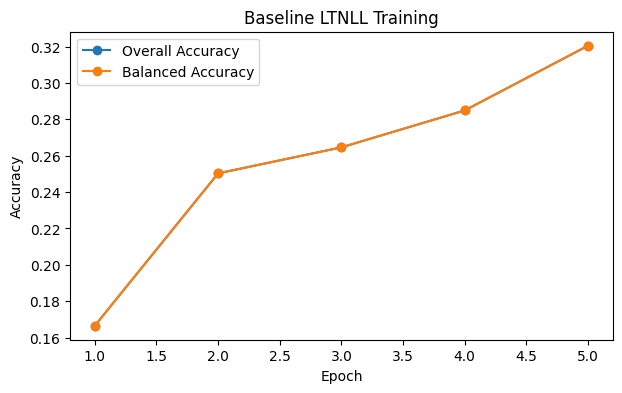

In [19]:
# Plot baseline
history_df = pd.DataFrame(history)

plt.figure(figsize=(7, 4))

plt.plot(
    history_df["epoch"],
    history_df["test_acc"],
    marker="o",
    label="Overall Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["balanced_acc"],
    marker="o",
    label="Balanced Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline LTNLL Training")

plt.legend()
plt.show()

In [20]:
# Step 2 — Signal 1: Prediction Confidence (C)
# Deterministic dataset for reliability analysis
analysis_dataset = LTNLLDataset(
    base_dataset=train_raw,
    selected_indices=lt_indices,
    noisy_labels=noisy_labels,
    clean_labels=clean_labels,
    transform=test_transform
)

analysis_loader = DataLoader(
    analysis_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Analysis samples:", len(analysis_dataset))

Analysis samples: 20431


In [21]:
import torch.nn.functional as F

model.eval()

n_samples = len(analysis_dataset)

observed_confidence = np.zeros(n_samples, dtype=np.float32)
max_confidence = np.zeros(n_samples, dtype=np.float32)
predicted_labels = np.zeros(n_samples, dtype=np.int64)

with torch.inference_mode():

    for images, noisy_y, clean_y, indices in analysis_loader:

        images = images.to(device)

        logits = model(images)
        probabilities = F.softmax(logits, dim=1)

        noisy_y_device = noisy_y.to(device)

        # Confidence assigned to the observed/training label
        batch_observed_conf = probabilities[
            torch.arange(len(images), device=device),
            noisy_y_device
        ]

        # Highest probability predicted by the network
        batch_max_conf, batch_pred = probabilities.max(dim=1)

        idx_np = indices.numpy()

        observed_confidence[idx_np] = batch_observed_conf.cpu().numpy()
        max_confidence[idx_np] = batch_max_conf.cpu().numpy()
        predicted_labels[idx_np] = batch_pred.cpu().numpy()

print("Finished collecting confidence scores.")

Finished collecting confidence scores.


In [22]:
sample_info["observed_confidence"] = observed_confidence
sample_info["max_confidence"] = max_confidence
sample_info["predicted_label"] = predicted_labels

sample_info.head(10)

,dataset_index,clean_label,noisy_label,is_noisy,group,observed_confidence,max_confidence,predicted_label
0,25276,2,2,False,Head,0.252779,0.252779,2
1,29468,0,0,False,Head,0.639683,0.639683,0
2,18395,8,8,False,Tail,0.084963,0.239909,2
3,13244,1,1,False,Head,0.783054,0.783054,1
4,4265,1,1,False,Head,0.066786,0.212279,0
5,25116,7,7,False,Tail,0.110575,0.196683,2
6,34523,8,8,False,Tail,0.124750,0.337287,0
7,17815,1,1,False,Head,0.832972,0.832972,1
8,36822,3,3,False,Medium,0.177917,0.241946,2
9,20338,3,5,True,Medium,0.103410,0.212748,3


In [23]:
print("Number of scores:", len(observed_confidence))
print("Minimum confidence:", observed_confidence.min())
print("Maximum confidence:", observed_confidence.max())
print("Any NaN values?:", np.isnan(observed_confidence).any())

Number of scores: 20431
Minimum confidence: 0.001133955
Maximum confidence: 0.9330888
Any NaN values?: False


In [24]:
# Clean vs Noisy confidence compare
clean_mean = sample_info.loc[
    sample_info["is_noisy"] == False,
    "observed_confidence"
].mean()

noisy_mean = sample_info.loc[
    sample_info["is_noisy"] == True,
    "observed_confidence"
].mean()

print(f"Mean confidence — Clean samples: {clean_mean:.4f}")
print(f"Mean confidence — Noisy samples: {noisy_mean:.4f}")

Mean confidence — Clean samples: 0.3442
Mean confidence — Noisy samples: 0.0758


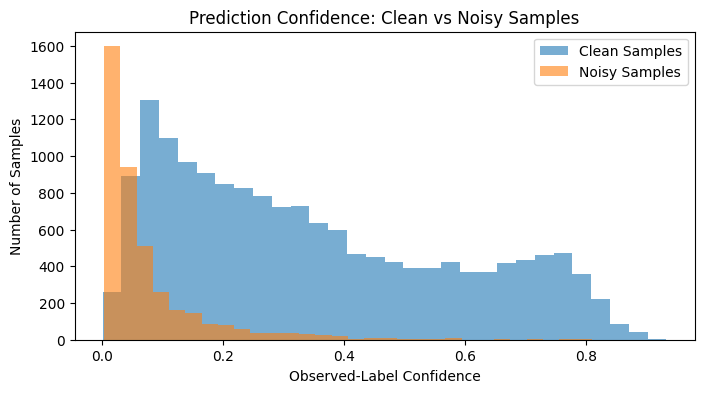

In [25]:
clean_scores = sample_info.loc[
    sample_info["is_noisy"] == False,
    "observed_confidence"
]

noisy_scores = sample_info.loc[
    sample_info["is_noisy"] == True,
    "observed_confidence"
]

plt.figure(figsize=(8, 4))

plt.hist(
    clean_scores,
    bins=30,
    alpha=0.6,
    label="Clean Samples"
)

plt.hist(
    noisy_scores,
    bins=30,
    alpha=0.6,
    label="Noisy Samples"
)

plt.xlabel("Observed-Label Confidence")
plt.ylabel("Number of Samples")
plt.title("Prediction Confidence: Clean vs Noisy Samples")
plt.legend()

plt.show()

In [26]:
# Head / Medium / Tail clean samples compare
clean_only = sample_info[
    sample_info["is_noisy"] == False
]

group_confidence = clean_only.groupby("group")[
    "observed_confidence"
].mean()

print(group_confidence)

group
Head      0.465687
Medium    0.201202
Tail      0.093228
Name: observed_confidence, dtype: float32


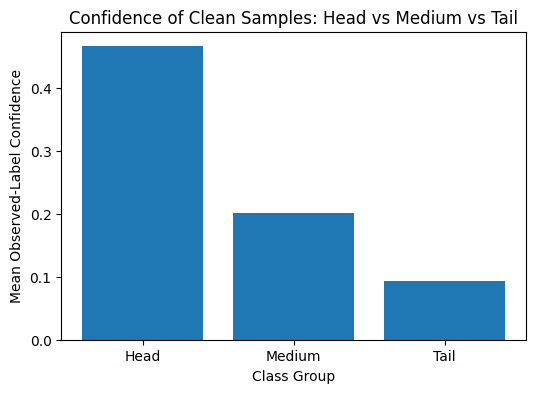

In [27]:
group_confidence = group_confidence.reindex(
    ["Head", "Medium", "Tail"]
)

plt.figure(figsize=(6, 4))

plt.bar(
    group_confidence.index,
    group_confidence.values
)

plt.xlabel("Class Group")
plt.ylabel("Mean Observed-Label Confidence")
plt.title("Confidence of Clean Samples: Head vs Medium vs Tail")

plt.show()

In [28]:
from sklearn.metrics import roc_auc_score, average_precision_score

# 1 = clean sample
# 0 = noisy sample
is_clean = (~sample_info["is_noisy"]).astype(int)

confidence_auc = roc_auc_score(
    is_clean,
    sample_info["observed_confidence"]
)

confidence_ap = average_precision_score(
    is_clean,
    sample_info["observed_confidence"]
)

print(f"Confidence AUROC: {confidence_auc:.4f}")
print(f"Confidence Average Precision: {confidence_ap:.4f}")

Confidence AUROC: 0.8974
Confidence Average Precision: 0.9684


In [29]:
# Confidence analysis by Head / Medium / Tail
# Compare CLEAN vs NOISY samples inside each group

group_results = []

for group in ["Head", "Medium", "Tail"]:

    group_data = sample_info[
        sample_info["group"] == group
    ]

    clean_group = group_data[
        group_data["is_noisy"] == False
    ]

    noisy_group = group_data[
        group_data["is_noisy"] == True
    ]

    clean_mean = clean_group["observed_confidence"].mean()
    noisy_mean = noisy_group["observed_confidence"].mean()

    group_auc = roc_auc_score(
        (~group_data["is_noisy"]).astype(int),
        group_data["observed_confidence"]
    )

    group_results.append({
        "Group": group,
        "Clean Samples": len(clean_group),
        "Noisy Samples": len(noisy_group),
        "Clean Mean Confidence": clean_mean,
        "Noisy Mean Confidence": noisy_mean,
        "Confidence AUROC": group_auc
    })

group_results_df = pd.DataFrame(group_results)

group_results_df

,Group,Clean Samples,Noisy Samples,Clean Mean Confidence,Noisy Mean Confidence,Confidence AUROC
0,Head,9484,2384,0.465687,0.062032,0.965170
1,Medium,5284,1300,0.201202,0.091588,0.806053
2,Tail,1577,402,0.093228,0.106220,0.635010


# Step 3 — Signal 2: Temporal Prediction Consistency (T)

Goal:
Track each sample's predictions across training epochs and measure
how consistently the model predicts the same class over time.

In [30]:
# Fresh model for temporal-history experiment

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model_t = models.resnet18(weights=None)

model_t.conv1 = nn.Conv2d(
    3,
    64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)

model_t.maxpool = nn.Identity()

model_t.fc = nn.Linear(
    model_t.fc.in_features,
    NUM_CLASSES
)

model_t = model_t.to(device)

print("Fresh temporal model created:", model_t.__class__.__name__)

Fresh temporal model created: ResNet


In [31]:
TEMP_EPOCHS = 20

criterion_t = nn.CrossEntropyLoss()

optimizer_t = optim.SGD(
    model_t.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler_t = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_t,
    T_max=TEMP_EPOCHS
)

print("Temporal experiment epochs:", TEMP_EPOCHS)

Temporal experiment epochs: 20


In [32]:
@torch.inference_mode()
def collect_predictions(model, loader, device, n_samples, num_classes):

    model.eval()

    probabilities_all = np.zeros(
        (n_samples, num_classes),
        dtype=np.float32
    )

    predicted_labels_all = np.zeros(
        n_samples,
        dtype=np.int64
    )

    for images, noisy_y, clean_y, indices in loader:

        images = images.to(device)

        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)

        predicted_labels = probabilities.argmax(dim=1)

        idx_np = indices.numpy()

        probabilities_all[idx_np] = probabilities.cpu().numpy()
        predicted_labels_all[idx_np] = predicted_labels.cpu().numpy()

    return probabilities_all, predicted_labels_all

In [33]:
n_samples = len(analysis_dataset)

probability_history = np.zeros(
    (TEMP_EPOCHS, n_samples, NUM_CLASSES),
    dtype=np.float32
)

predicted_label_history = np.zeros(
    (TEMP_EPOCHS, n_samples),
    dtype=np.int64
)

temporal_history = []

print("Probability history shape:", probability_history.shape)
print("Label history shape:", predicted_label_history.shape)

Probability history shape: (20, 20431, 10)
Label history shape: (20, 20431)


In [34]:
for epoch in range(TEMP_EPOCHS):

    # 1. Train one epoch using noisy labels
    train_loss, train_acc = train_one_epoch(
        model_t,
        train_loader,
        optimizer_t,
        criterion_t,
        device
    )

    # 2. Evaluate on clean test set
    test_acc, balanced_acc, class_acc = evaluate(
        model_t,
        test_loader,
        device
    )

    # 3. Record EVERY training sample prediction
    epoch_probs, epoch_preds = collect_predictions(
        model_t,
        analysis_loader,
        device,
        n_samples,
        NUM_CLASSES
    )

    probability_history[epoch] = epoch_probs
    predicted_label_history[epoch] = epoch_preds

    scheduler_t.step()

    temporal_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "balanced_acc": balanced_acc
    })

    print(
        f"Epoch {epoch+1:02d}/{TEMP_EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"Balanced Acc: {balanced_acc:.4f}"
    )

Epoch 01/20 | Loss: 2.5292 | Train Acc: 0.2157 | Test Acc: 0.1706 | Balanced Acc: 0.1706
Epoch 02/20 | Loss: 2.0177 | Train Acc: 0.2897 | Test Acc: 0.1926 | Balanced Acc: 0.1926
Epoch 03/20 | Loss: 1.9295 | Train Acc: 0.3355 | Test Acc: 0.2364 | Balanced Acc: 0.2364
Epoch 04/20 | Loss: 1.8758 | Train Acc: 0.3628 | Test Acc: 0.2632 | Balanced Acc: 0.2632
Epoch 05/20 | Loss: 1.8377 | Train Acc: 0.3785 | Test Acc: 0.2683 | Balanced Acc: 0.2683
Epoch 06/20 | Loss: 1.7980 | Train Acc: 0.4046 | Test Acc: 0.2996 | Balanced Acc: 0.2996
Epoch 07/20 | Loss: 1.7597 | Train Acc: 0.4188 | Test Acc: 0.3201 | Balanced Acc: 0.3201
Epoch 08/20 | Loss: 1.7257 | Train Acc: 0.4327 | Test Acc: 0.3832 | Balanced Acc: 0.3832
Epoch 09/20 | Loss: 1.6880 | Train Acc: 0.4505 | Test Acc: 0.3905 | Balanced Acc: 0.3905
Epoch 10/20 | Loss: 1.6550 | Train Acc: 0.4687 | Test Acc: 0.3986 | Balanced Acc: 0.3986
Epoch 11/20 | Loss: 1.6314 | Train Acc: 0.4787 | Test Acc: 0.4425 | Balanced Acc: 0.4425
Epoch 12/20 | Loss: 1

In [35]:
print("Probability history:", probability_history.shape)
print("Predicted-label history:", predicted_label_history.shape)

print("\nExample — Sample 0 predicted labels across epochs:")
print(predicted_label_history[:, 0])

print("\nExample — Sample 0:")
print("Clean label:", clean_labels[0])
print("Observed/noisy label:", noisy_labels[0])
print("Actually noisy?:", is_noisy[0])

Probability history: (20, 20431, 10)
Predicted-label history: (20, 20431)

Example — Sample 0 predicted labels across epochs:
[1 1 0 0 0 2 2 5 5 0 2 0 2 2 5 2 2 2 2 2]

Example — Sample 0:
Clean label: 2
Observed/noisy label: 2
Actually noisy?: False


In [36]:
# Compare consecutive epoch predictions
same_as_previous = (
    predicted_label_history[1:] ==
    predicted_label_history[:-1]
)

# Average consistency for every sample
temporal_consistency = same_as_previous.mean(axis=0).astype(np.float32)

print("Number of T scores:", len(temporal_consistency))
print("Minimum T:", temporal_consistency.min())
print("Maximum T:", temporal_consistency.max())
print("Mean T:", temporal_consistency.mean())
print("Any NaN?:", np.isnan(temporal_consistency).any())

Number of T scores: 20431
Minimum T: 0.0
Maximum T: 1.0
Mean T: 0.73294455
Any NaN?: False


In [37]:
sample_info["temporal_consistency"] = temporal_consistency

sample_info[
    [
        "clean_label",
        "noisy_label",
        "is_noisy",
        "group",
        "observed_confidence",
        "temporal_consistency"
    ]
].head(10)

,clean_label,noisy_label,is_noisy,group,observed_confidence,temporal_consistency
0,2,2,False,Head,0.252779,0.526316
1,0,0,False,Head,0.639683,1.000000
2,8,8,False,Tail,0.084963,0.578947
3,1,1,False,Head,0.783054,0.947368
4,1,1,False,Head,0.066786,0.421053
5,7,7,False,Tail,0.110575,0.736842
6,8,8,False,Tail,0.124750,0.736842
7,1,1,False,Head,0.832972,1.000000
8,3,3,False,Medium,0.177917,0.578947
9,3,5,True,Medium,0.103410,0.263158


In [38]:
clean_t_mean = sample_info.loc[
    sample_info["is_noisy"] == False,
    "temporal_consistency"
].mean()

noisy_t_mean = sample_info.loc[
    sample_info["is_noisy"] == True,
    "temporal_consistency"
].mean()

print(f"Mean T — Clean samples: {clean_t_mean:.4f}")
print(f"Mean T — Noisy samples: {noisy_t_mean:.4f}")

Mean T — Clean samples: 0.7339
Mean T — Noisy samples: 0.7293


In [39]:
t_auc = roc_auc_score(
    is_clean,
    sample_info["temporal_consistency"]
)

t_ap = average_precision_score(
    is_clean,
    sample_info["temporal_consistency"]
)

print(f"Temporal Consistency AUROC: {t_auc:.4f}")
print(f"Temporal Consistency Average Precision: {t_ap:.4f}")

Temporal Consistency AUROC: 0.5062
Temporal Consistency Average Precision: 0.8024


In [40]:
temporal_group_results = []

for group in ["Head", "Medium", "Tail"]:

    group_data = sample_info[
        sample_info["group"] == group
    ]

    clean_group = group_data[
        group_data["is_noisy"] == False
    ]

    noisy_group = group_data[
        group_data["is_noisy"] == True
    ]

    clean_mean_t = clean_group[
        "temporal_consistency"
    ].mean()

    noisy_mean_t = noisy_group[
        "temporal_consistency"
    ].mean()

    group_auc_t = roc_auc_score(
        (~group_data["is_noisy"]).astype(int),
        group_data["temporal_consistency"]
    )

    temporal_group_results.append({
        "Group": group,
        "Clean Mean T": clean_mean_t,
        "Noisy Mean T": noisy_mean_t,
        "Temporal AUROC": group_auc_t
    })

temporal_group_results_df = pd.DataFrame(
    temporal_group_results
)

temporal_group_results_df

,Group,Clean Mean T,Noisy Mean T,Temporal AUROC
0,Head,0.811067,0.807025,0.507455
1,Medium,0.606548,0.597773,0.515779
2,Tail,0.696025,0.693899,0.503904


In [41]:
comparison_CT = pd.DataFrame({
    "Group": ["Head", "Medium", "Tail"],
    "Confidence_AUROC": group_results_df[
        "Confidence AUROC"
    ].values,
    "Temporal_AUROC": temporal_group_results_df[
        "Temporal AUROC"
    ].values
})

comparison_CT

,Group,Confidence_AUROC,Temporal_AUROC
0,Head,0.965170,0.507455
1,Medium,0.806053,0.515779
2,Tail,0.635010,0.503904


In [42]:
# Confidence C for every sample at every epoch
# C_i(t) = probability assigned to the observed/noisy label

observed_labels_array = np.asarray(noisy_labels, dtype=np.int64)

confidence_history = np.zeros(
    (TEMP_EPOCHS, n_samples),
    dtype=np.float32
)

for epoch in range(TEMP_EPOCHS):
    confidence_history[epoch] = probability_history[
        epoch,
        np.arange(n_samples),
        observed_labels_array
    ]

print("Confidence history shape:", confidence_history.shape)
print("Example sample 0 C across epochs:")
print(confidence_history[:, 0])

Confidence history shape: (20, 20431)
Example sample 0 C across epochs:
[0.15130307 0.0812809  0.16024537 0.10706466 0.13041846 0.20254785
 0.24383192 0.0800685  0.13657436 0.20030911 0.24563368 0.18602824
 0.2281431  0.31264788 0.24515827 0.34192988 0.30398932 0.61321455
 0.53127337 0.5554893 ]


In [43]:
temporal_consistency_history = np.zeros(
    (TEMP_EPOCHS, n_samples),
    dtype=np.float32
)

# Epoch 1ට previous prediction නැති නිසා T = 0
temporal_consistency_history[0] = 0.0

same_prev = (
    predicted_label_history[1:] ==
    predicted_label_history[:-1]
).astype(np.float32)

for epoch in range(1, TEMP_EPOCHS):
    # Consistency from epoch 1 up to current epoch
    temporal_consistency_history[epoch] = (
        same_prev[:epoch].mean(axis=0)
    )

print(
    "Temporal history shape:",
    temporal_consistency_history.shape
)

print("Example sample 0 T across epochs:")
print(temporal_consistency_history[:, 0])

Temporal history shape: (20, 20431)
Example sample 0 T across epochs:
[0.         1.         0.5        0.6666667  0.75       0.6
 0.6666667  0.5714286  0.625      0.5555556  0.5        0.45454547
 0.41666666 0.46153846 0.42857143 0.4        0.4375     0.47058824
 0.5        0.5263158 ]


In [44]:
ct_epoch_results = []

clean_targets_binary = (~np.asarray(is_noisy)).astype(int)

for epoch in range(1, TEMP_EPOCHS):

    c_auc = roc_auc_score(
        clean_targets_binary,
        confidence_history[epoch]
    )

    t_auc_epoch = roc_auc_score(
        clean_targets_binary,
        temporal_consistency_history[epoch]
    )

    ct_epoch_results.append({
        "Epoch": epoch + 1,
        "Confidence_AUROC": c_auc,
        "Temporal_AUROC": t_auc_epoch
    })

ct_epoch_df = pd.DataFrame(ct_epoch_results)

ct_epoch_df

,Epoch,Confidence_AUROC,Temporal_AUROC
0,2,0.797116,0.506803
1,3,0.838758,0.502840
2,4,0.859313,0.503272
3,5,0.868507,0.503150
4,6,0.884881,0.504477
5,7,0.874067,0.502125
6,8,0.897589,0.502638
7,9,0.908206,0.501878
8,10,0.914835,0.500679
9,11,0.917760,0.500767


In [45]:
print(ct_epoch_df.head())

   Epoch  Confidence_AUROC  Temporal_AUROC
0      2          0.797116        0.506803
1      3          0.838758        0.502840
2      4          0.859313        0.503272
3      5          0.868507        0.503150
4      6          0.884881        0.504477


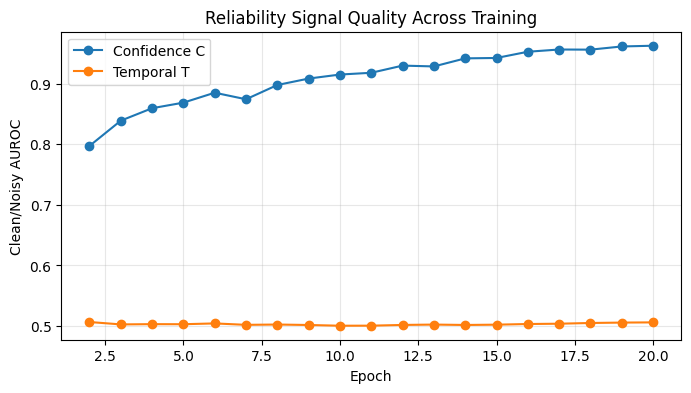

In [46]:
plt.figure(figsize=(8, 4))

plt.plot(
    ct_epoch_df["Epoch"],
    ct_epoch_df["Confidence_AUROC"],
    marker="o",
    label="Confidence C"
)

plt.plot(
    ct_epoch_df["Epoch"],
    ct_epoch_df["Temporal_AUROC"],
    marker="o",
    label="Temporal T"
)

plt.xlabel("Epoch")
plt.ylabel("Clean/Noisy AUROC")
plt.title("Reliability Signal Quality Across Training")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [47]:
print("Probability history shape:", probability_history.shape)
print("Expected:", (TEMP_EPOCHS, n_samples, NUM_CLASSES))

Probability history shape: (20, 20431, 10)
Expected: (20, 20431, 10)


# Step 3B — Improved Probability-Based Temporal Consistency (T-v1)

Instead of checking only whether the predicted class stays the same,
this version compares the full current prediction distribution with an
EMA summary of the sample's previous predictions.

In [48]:
from scipy.spatial.distance import jensenshannon

BETA_T = 0.9

# T-v1 score for every epoch and every sample
temporal_prob_history = np.full(
    (TEMP_EPOCHS, n_samples),
    np.nan,
    dtype=np.float32
)

# Historical EMA starts from epoch 1 predictions
ema_predictions = probability_history[0].copy()

for epoch in range(1, TEMP_EPOCHS):

    current_predictions = probability_history[epoch]

    # Jensen-Shannon distance between:
    # current prediction distribution
    # and historical EMA prediction distribution
    js_distance = jensenshannon(
        current_predictions,
        ema_predictions,
        base=2,
        axis=1
    )

    # Convert distance to consistency:
    # 1 = very stable
    # 0 = very different
    temporal_prob_history[epoch] = (
        1.0 - js_distance
    ).astype(np.float32)

    # Update EMA AFTER calculating T,
    # so current epoch is not included in its own history
    ema_predictions = (
        BETA_T * ema_predictions
        + (1.0 - BETA_T) * current_predictions
    )

print("T-v1 history shape:", temporal_prob_history.shape)

print("\nExample sample 0 T-v1 across epochs:")
print(temporal_prob_history[:, 0])

print("\nT-v1 min:",
      np.nanmin(temporal_prob_history))
print("T-v1 max:",
      np.nanmax(temporal_prob_history))

T-v1 history shape: (20, 20431)

Example sample 0 T-v1 across epochs:
[       nan 0.81334585 0.8087063  0.78723484 0.8750367  0.7553905
 0.70374846 0.579136   0.75689995 0.82229894 0.87929636 0.90174806
 0.827116   0.75697416 0.6488271  0.7125477  0.70117664 0.628296
 0.68850225 0.72958475]

T-v1 min: 0.08889389
T-v1 max: 0.97679204


In [49]:
final_t_prob = temporal_prob_history[-1]

clean_tprob_mean = final_t_prob[
    np.asarray(is_noisy) == False
].mean()

noisy_tprob_mean = final_t_prob[
    np.asarray(is_noisy) == True
].mean()

print(
    f"Final T-v1 — Clean mean: {clean_tprob_mean:.4f}"
)
print(
    f"Final T-v1 — Noisy mean: {noisy_tprob_mean:.4f}"
)

tprob_auc = roc_auc_score(
    clean_targets_binary,
    final_t_prob
)

tprob_ap = average_precision_score(
    clean_targets_binary,
    final_t_prob
)

print(
    f"Final T-v1 AUROC: {tprob_auc:.4f}"
)
print(
    f"Final T-v1 Average Precision: {tprob_ap:.4f}"
)

Final T-v1 — Clean mean: 0.7875
Final T-v1 — Noisy mean: 0.7978
Final T-v1 AUROC: 0.4638
Final T-v1 Average Precision: 0.7855


In [50]:
tprob_group_results = []

for group in ["Head", "Medium", "Tail"]:

    mask = (
        sample_info["group"].values == group
    )

    group_clean_truth = (
        ~np.asarray(is_noisy)[mask]
    ).astype(int)

    group_scores = final_t_prob[mask]

    clean_scores = group_scores[
        group_clean_truth == 1
    ]

    noisy_scores = group_scores[
        group_clean_truth == 0
    ]

    group_auc = roc_auc_score(
        group_clean_truth,
        group_scores
    )

    tprob_group_results.append({
        "Group": group,
        "Clean Mean T-v1": clean_scores.mean(),
        "Noisy Mean T-v1": noisy_scores.mean(),
        "T-v1 AUROC": group_auc
    })

tprob_group_df = pd.DataFrame(
    tprob_group_results
)

tprob_group_df

,Group,Clean Mean T-v1,Noisy Mean T-v1,T-v1 AUROC
0,Head,0.805927,0.812622,0.473013
1,Medium,0.771522,0.784735,0.451479
2,Tail,0.730170,0.752613,0.433932


In [51]:
comparison_temporal = pd.DataFrame({
    "Group": ["Head", "Medium", "Tail"],
    "T-v0_Argmax_AUROC":
        temporal_group_results_df[
            "Temporal AUROC"
        ].values,

    "T-v1_Probability_AUROC":
        tprob_group_df[
            "T-v1 AUROC"
        ].values
})

comparison_temporal

,Group,T-v0_Argmax_AUROC,T-v1_Probability_AUROC
0,Head,0.507455,0.473013
1,Medium,0.515779,0.451479
2,Tail,0.503904,0.433932


In [52]:
signal_epoch_results = []

for epoch in range(1, TEMP_EPOCHS):

    c_auc = roc_auc_score(
        clean_targets_binary,
        confidence_history[epoch]
    )

    t0_auc = roc_auc_score(
        clean_targets_binary,
        temporal_consistency_history[epoch]
    )

    t1_auc = roc_auc_score(
        clean_targets_binary,
        temporal_prob_history[epoch]
    )

    signal_epoch_results.append({
        "Epoch": epoch + 1,
        "Confidence_C": c_auc,
        "Temporal_T_v0": t0_auc,
        "Temporal_T_v1": t1_auc
    })

signal_epoch_df = pd.DataFrame(
    signal_epoch_results
)

signal_epoch_df

,Epoch,Confidence_C,Temporal_T_v0,Temporal_T_v1
0,2,0.797116,0.506803,0.492561
1,3,0.838758,0.502840,0.498884
2,4,0.859313,0.503272,0.501739
3,5,0.868507,0.503150,0.503429
4,6,0.884881,0.504477,0.501757
5,7,0.874067,0.502125,0.502963
6,8,0.897589,0.502638,0.506346
7,9,0.908206,0.501878,0.504955
8,10,0.914835,0.500679,0.506387
9,11,0.917760,0.500767,0.504512


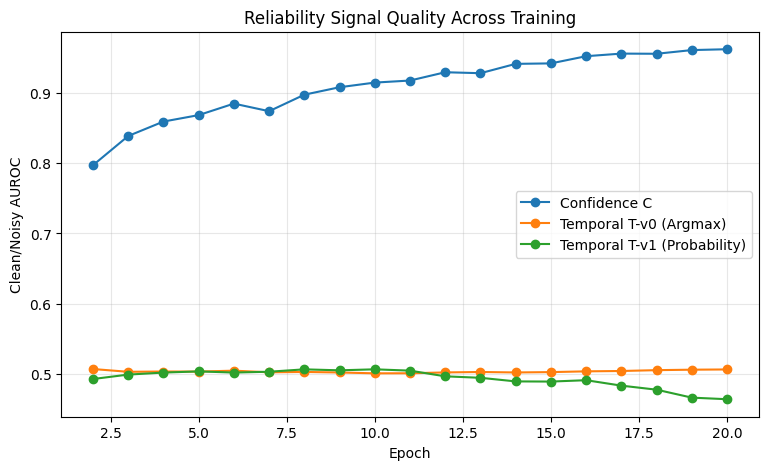

In [53]:
plt.figure(figsize=(9, 5))

plt.plot(
    signal_epoch_df["Epoch"],
    signal_epoch_df["Confidence_C"],
    marker="o",
    label="Confidence C"
)

plt.plot(
    signal_epoch_df["Epoch"],
    signal_epoch_df["Temporal_T_v0"],
    marker="o",
    label="Temporal T-v0 (Argmax)"
)

plt.plot(
    signal_epoch_df["Epoch"],
    signal_epoch_df["Temporal_T_v1"],
    marker="o",
    label="Temporal T-v1 (Probability)"
)

plt.xlabel("Epoch")
plt.ylabel("Clean/Noisy AUROC")
plt.title(
    "Reliability Signal Quality Across Training"
)
plt.legend()
plt.grid(alpha=0.3)

plt.show()